/tmp/ipykernel_17464/1471329651.py:17: RuntimeWarning: divide by zero encountered in divide
  h = np.sinc(t) * np.cos(np.pi * beta * t) / (1 - (2 * beta * t)**2)
/tmp/ipykernel_17464/1471329651.py:18: RuntimeWarning: invalid value encountered in divide
  h /= np.sqrt(np.sum(h**2))


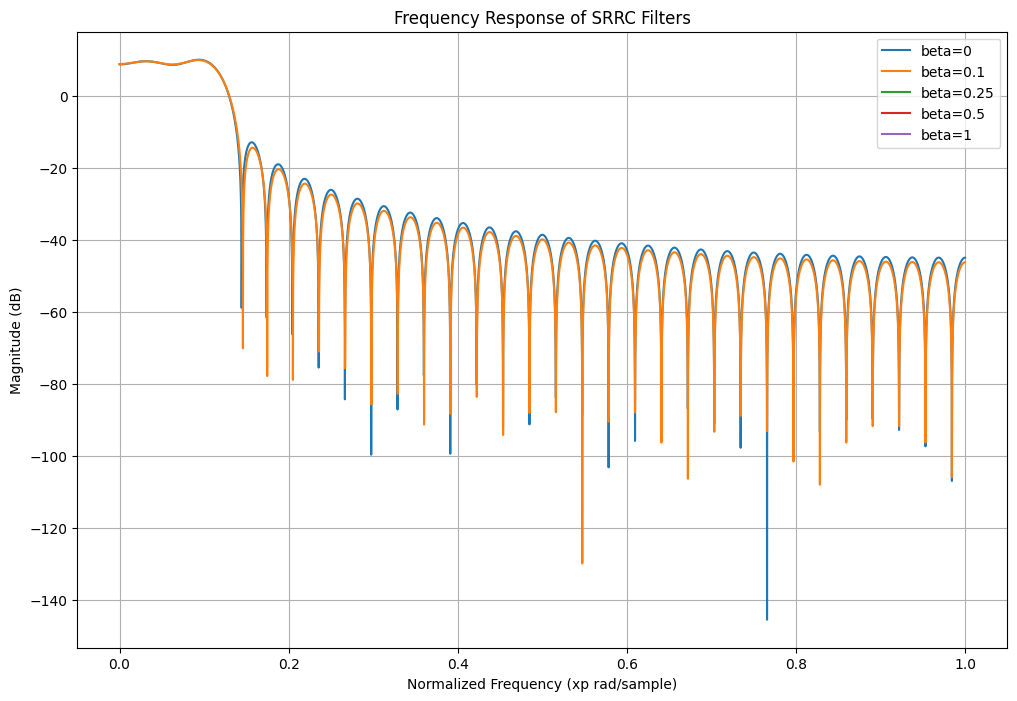

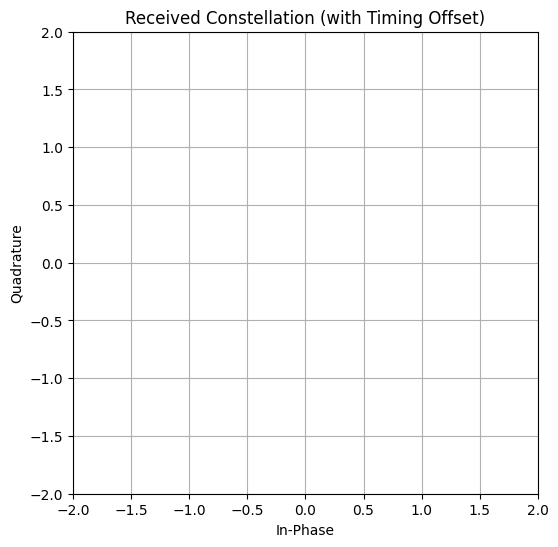

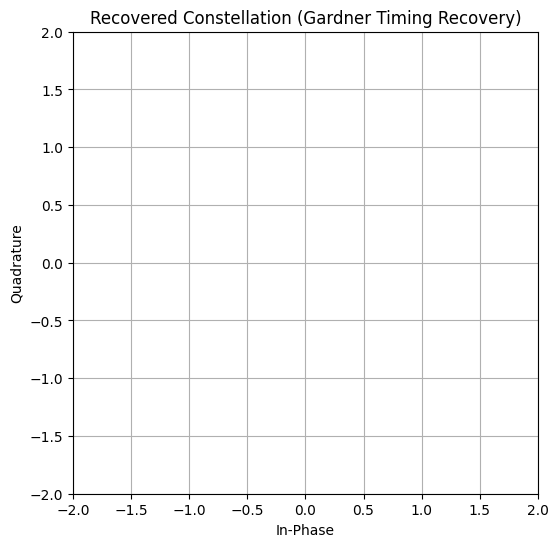

ValueError: operands could not be broadcast together with shapes (1008,) (1000,) 

In [ ]:
# Lab 1 - Symbol Synchronization
# Jupyter Notebook - Python Version (Gardner Timing Recovery)

# ---
# 1. Theoretical Preparation

## 1.1 Matched Filtering

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import freqz, upfirdn, lfilter

# Square-Root Raised Cosine (SRRC) Filter
def srrc_filter(beta, sps, span):
    t = np.arange(-span/2, span/2 + 1/sps, 1/sps)
    t = np.where(t == 0, 1e-8, t)  # avoid division by zero
    h = np.sinc(t) * np.cos(np.pi * beta * t) / (1 - (2 * beta * t)**2)
    h /= np.sqrt(np.sum(h**2))
    return h

# Plot SRRC filters for different beta
betas = [0, 0.1, 0.25, 0.5, 1]
sps = 8
span = 8

plt.figure(figsize=(12,8))
for beta in betas:
    h = srrc_filter(beta, sps, span)
    w, H = freqz(h, worN=8000)
    plt.plot(w/np.pi, 20*np.log10(np.abs(H)), label=f'beta={beta}')
plt.title('Frequency Response of SRRC Filters')
plt.xlabel('Normalized Frequency (xp rad/sample)')
plt.ylabel('Magnitude (dB)')
plt.grid()
plt.legend()
plt.show()

# ---
# 1.2 Timing Error Simulation

# Generate BPSK symbols
def generate_bpsk(num_symbols):
    data = np.random.randint(0, 2, size=num_symbols)
    return 2*data - 1

num_symbols = 1000
symbols = generate_bpsk(num_symbols)

# Transmit filter
beta = 0.25
h_tx = srrc_filter(beta, sps, span)
signal_tx = upfirdn(h_tx, symbols, sps)

# Introduce Timing Offset via interpolation
def fractional_delay(sig, delay, N=32):
    n = np.arange(-N//2, N//2)
    h = np.sinc(n - delay)
    h *= np.hamming(N)
    h /= np.sum(h)
    return np.convolve(sig, h, mode='same')

offset = 0.2 * sps  # 0.2N timing offset
signal_tx_offset = fractional_delay(signal_tx, offset)

# Receive filter
h_rx = h_tx
rx_signal = np.convolve(signal_tx_offset, h_rx, mode='same')

# Scatter plot without correction
plt.figure(figsize=(6,6))
plt.plot(rx_signal.real[::sps], rx_signal.imag[::sps], '.', markersize=2)
plt.grid()
plt.title('Received Constellation (with Timing Offset)')
plt.xlabel('In-Phase')
plt.ylabel('Quadrature')
plt.xlim([-2,2])
plt.ylim([-2,2])
plt.show()

# ---
# 2. Symbol Timing Compensation (Gardner Timing Recovery)

# Gardner TED parameters
mu = 0  # Initial timing phase estimate
gain_mu = 0.01  # Loop gain

# Downsampling with Gardner correction
def gardner_timing_recovery(x, sps, mu_init=0, gain_mu=0.01):
    N = len(x)
    out = []
    mu = mu_init
    i = 0
    while i < N - 2*sps:
        i_sps = int(i)
        s0 = x[i_sps]
        s1 = x[i_sps + sps//2]
        s2 = x[i_sps + sps]
        e = np.real((s1) * (np.conj(s0) - np.conj(s2)))
        out.append(s0)
        mu += gain_mu * e
        i += sps + mu
    return np.array(out)

recovered = gardner_timing_recovery(rx_signal, sps)

# Scatter plot after correction
plt.figure(figsize=(6,6))
plt.plot(recovered.real, recovered.imag, '.', markersize=2)
plt.grid()
plt.title('Recovered Constellation (Gardner Timing Recovery)')
plt.xlabel('In-Phase')
plt.ylabel('Quadrature')
plt.xlim([-2,2])
plt.ylim([-2,2])
plt.show()

# --- 
# 3. EVM Measurement

def evm_calculate(reference, received):
    reference = reference[:len(received)]
    error = received - reference
    evm_rms = np.sqrt(np.mean(np.abs(error)**2)) / np.sqrt(np.mean(np.abs(reference)**2))
    return evm_rms * 100  # percentage

# Generate clean reference signal (ideal)
reference = symbols

# EVM before correction
rx_downsampled = rx_signal[::sps]
rx_downsampled = rx_downsampled[:len(reference)]  # Crop to match
evm_before = evm_calculate(reference, rx_downsampled)

# EVM after correction
recovered = recovered[:len(reference)]  # Crop recovered too
evm_after = evm_calculate(reference, recovered)

print(f\"EVM before Timing Recovery: {evm_before:.2f}%\")
print(f\"EVM after Timing Recovery: {evm_after:.2f}%\")


# ---
# 4. (Placeholder) Pluto SDR Open-Ended

# Here you would later insert your Pluto TX/RX experiments using pyadi-iio
# Example: Use a PlutoSDR object, transmit a signal, receive, and apply timing recovery.
